# MSE 413 Lab 1 Assignment

## Background

There are 4 regression models use to predict outcomes depending on the number of independence variables

- Linear regression finds the linear relationship between one outcome and one input based on a pretrained set of inputs and outputs
$$ y \approx a + a+1x_1$$

- Multiple linear regression finds the linear relationship between one outcomes based on multiple different inputs. Each input has a different impact on predicting the outcome.
$$ y \approx a + a_1x_1 + a_2x_2 + ... + a_nx_n$$

- Polynomial regression is a generalized case of linear regression when an outcome has a polynomial dependence on one input.
$$ y \approx a + a_1x_1 + a_2x_2^2 + ... + a_nx_n^n$$

- Non-linear regression is applied when linear regression models are not fit to for predicting the outcomes, as the relationship between input and outcome are not linear or polynomial relationship.

## Objectives
- Explore the whole workflow of a machine learning problem
- Familiaize to Python's machine learning related libraries such as Pandas, NumPy and Scikit-Learn
- Familiarize to data visualiztion with Python libraries, such as Seaborn and Matplotlib

### Main steps of a machine learning project

- Frame the problem: Identify inputs and outputs, type of problem (supervised/ unsupervised), and type of task (regression, classification, etc)
- Get the data
- Discover and visualize the data to get insight
- Prepare the data for machine learning algorithm
- Select a model and train it on training dataset
- Performance measurement and model tuning to eliminate any overfitting
- Model generalization


## Assignment

### Data discovery

1. Import all the essential libraries and load the datasets into Python.

In [1]:
import pandas as pd
import seaborn as sns

2. Concatenate data from all five years into a single dataframe named gt_df

In [2]:
# Concanate the data
gt_2011 = pd.read_csv('data/gt_2011.csv')
gt_2012 = pd.read_csv('data/gt_2012.csv')
gt_2013 = pd.read_csv('data/gt_2013.csv')
gt_2014 = pd.read_csv('data/gt_2014.csv')
gt_2015 = pd.read_csv('data/gt_2015.csv')

gt_df = pd.concat([gt_2011, gt_2012, gt_2013, gt_2014, gt_2015])

# Save the data
gt_df.to_csv('data/gt_df.csv', index=False)

3. Evaluate the shape and size of your final dataframe and report it. Is it consistent with the total number of data mentioned above?

Ans: The data is consistent and preserved in a single dataframe. The number of entries matches the sum of all individual entries.

In [3]:
gt_df.head(5)

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952
1,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377
2,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776
3,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505
4,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028


In [4]:
# Check the data.
print(gt_2011.shape)
print(gt_2012.shape)
print(gt_2013.shape)
print(gt_2014.shape)
print(gt_2015.shape)
print(f"The shape of the concatenated data is: {gt_df.shape} and\nthe consistency with the total number of rows: {gt_df.shape[0] == gt_2011.shape[0] + gt_2012.shape[0] + gt_2013.shape[0] + gt_2014.shape[0] + gt_2015.shape[0]}")

(7411, 11)
(7628, 11)
(7152, 11)
(7158, 11)
(7384, 11)
The shape of the concatenated data is: (36733, 11) and
the consistency with the total number of rows: True


4. Use the .info() method to see the type of all features and whether there is any null or missing value in your dataset.

Ans: There is no missing data or null data because the number of non-null entries matches the total number of entries in the data frame.

In [5]:
gt_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36733 entries, 0 to 7383
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      36733 non-null  float64
 1   AP      36733 non-null  float64
 2   AH      36733 non-null  float64
 3   AFDP    36733 non-null  float64
 4   GTEP    36733 non-null  float64
 5   TIT     36733 non-null  float64
 6   TAT     36733 non-null  float64
 7   TEY     36733 non-null  float64
 8   CDP     36733 non-null  float64
 9   CO      36733 non-null  float64
 10  NOX     36733 non-null  float64
dtypes: float64(11)
memory usage: 3.4 MB


5. Get the general statistical description (.describe()) of your dataframe and report your observations. Can you find any skewness at this point, based on the comparison of mode, and mean.

Ans:
mean: 17.712726, 1013.070165, 77.867015, 3.925518, 25.563801, 1081.428084, 546.158517, 133.506404, 12.060525, 2.372468, 65.293067
mode: 11.920, 1012.1, 100.12, 3.2115, 24.308, 1100.0, 550.01, 133.78, 11.891, 0.11124, 60.38

- Positve skewness (mean > mode): AT, AH , TIT, TAT
- Negative skewness (mean > mode) AP,AFDP, GTEP, TEY, CDP, CO, NOX

In [6]:
# Get the skewness of the data
gt_df.skew()

AT     -0.043547
AP      0.194121
AH     -0.628034
AFDP    0.381097
GTEP    0.329021
TIT    -0.888278
TAT    -1.755907
TEY     0.116555
CDP     0.236792
CO      4.838174
NOX     1.026779
dtype: float64

In [7]:
gt_df.describe()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
count,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000
mean,17.712726,1013.070165,77.867015,3.925518,25.563801,1081.428084,546.158517,133.506404,12.060525,2.372468,65.293067
std,7.447451,6.463346,14.461355,0.773936,4.195957,17.536373,6.842360,15.618634,1.088795,2.262672,11.678357
min,-6.234800,985.850000,24.085000,2.087400,17.698000,1000.800000,511.040000,100.020000,9.851800,0.000388,25.905000
25%,11.781000,1008.800000,68.188000,3.355600,23.129000,1071.800000,544.720000,124.450000,11.435000,1.182400,57.162000
50%,17.801000,1012.600000,80.470000,3.937700,25.104000,1085.900000,549.880000,133.730000,11.965000,1.713500,63.849000
75%,23.665000,1017.000000,89.376000,4.376900,29.061000,1097.000000,550.040000,144.080000,12.855000,2.842900,71.548000
max,37.103000,1036.600000,100.200000,7.610600,40.716000,1100.900000,550.610000,179.500000,15.159000,44.103000,119.910000


In [8]:
# Get mode of the data
gt_df.mode()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,11.920,1012.1,100.12,3.2115,24.308,1100.0,550.01,133.78,11.891,0.11124,60.38
1,18.525,NaN,100.14,4.0076,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23.969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Get the histogram of all variables in your dataframe with 100 bins and answer the 
following questions based on your observations:

- Do you see any attribute/target with normal or semi-normal distribution? Which 
one(s)?
- Do you see any capped data? Which one(s)?
- Do you see multimodal distribution on any data? Which one(s)? Search on this 
type of distribution and report briefly (one paragraph) on how it affects ML 
modeling and how it can be handled in ML problems. 

Ans:
mean: 17.712726, 1013.070165, 77.867015, 3.925518, 25.563801, 1081.428084, 546.158517, 133.506404, 12.060525, 2.372468, 65.293067

Do you see any attribute/target with normal or semi-normal distribution? Which 
one(s)?
- Normal distribution: AP, NOX
- Semi-normal distribution: AH, ATDP

Do you see any capped data? Which one(s)?
- Graphs that has abrupt cut off at the boundary, a sharp peak at the cap, asymmetry in the distribuiton or discontinuity in the tail such as TIT, TAT, TEY and CO (sharp peak), and AH (discontinuity in the tail)

Do you see multimodal distribution on any data? Which one(s)? Search on this 
type of distribution and report briefly (one paragraph) on how it affects ML 
modeling and how it can be handled in ML problems.
- Multimodal distribution: AT, GTEP, CDP

For linear type model in machine learning, the multimodal distribution create bias, poor clustering performance, overfitting problems in supervised learning and feature dependence issues. For this kind of data, there are many nonlinear models that does not rely on the a single distribution such as decision trees, random forests, and neural network. Another approach to handle these data is to use mixture models to handle multiple distribution peaks. Feature engineering and transformation are alternative solutions to decluster the data, handpick and finetuning models better, in trade for more manual labor.

array([[<Axes: title={'center': 'AT'}>, <Axes: title={'center': 'AP'}>,
        <Axes: title={'center': 'AH'}>],
       [<Axes: title={'center': 'AFDP'}>,
        <Axes: title={'center': 'GTEP'}>,
        <Axes: title={'center': 'TIT'}>],
       [<Axes: title={'center': 'TAT'}>, <Axes: title={'center': 'TEY'}>,
        <Axes: title={'center': 'CDP'}>],
       [<Axes: title={'center': 'CO'}>, <Axes: title={'center': 'NOX'}>,
        <Axes: >]], dtype=object)

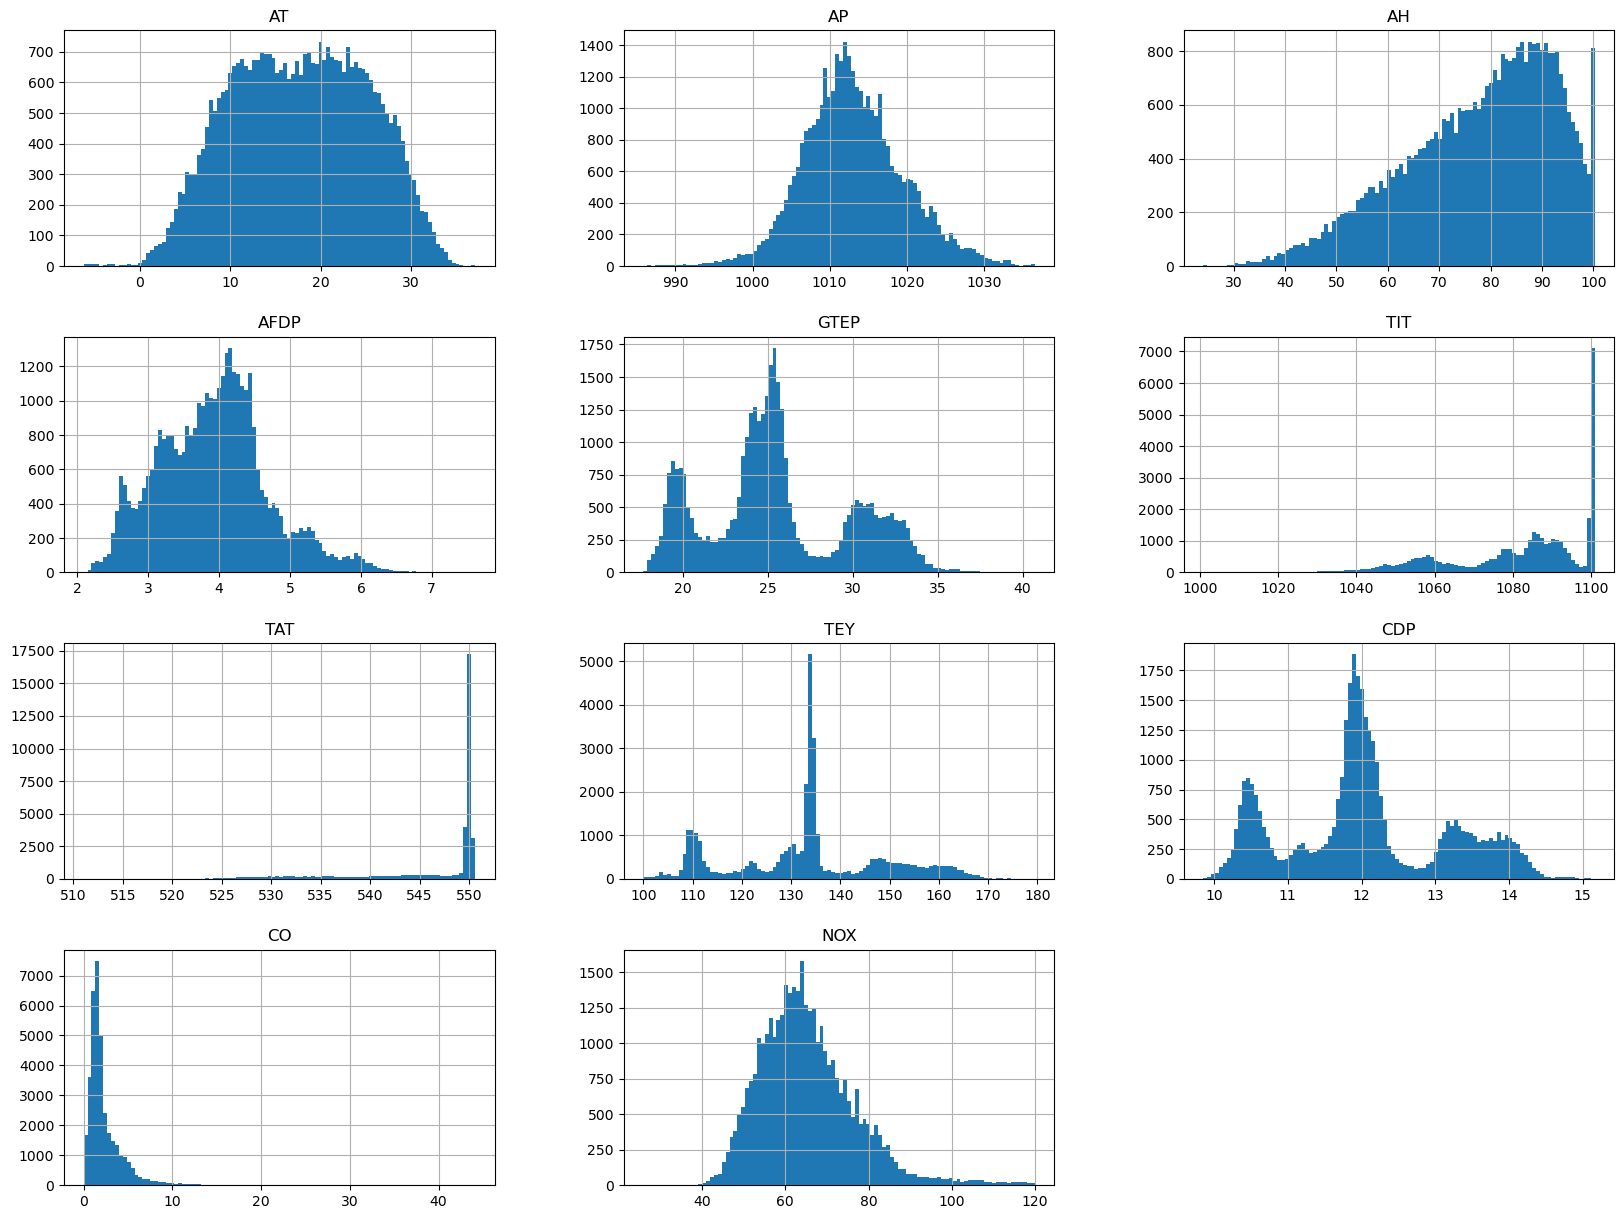

In [9]:
gt_df.hist(bins=100, figsize=(20,15))

7. According to what you have learned in the tutorial on the relationship between features, go through the following tasks:  

- Calculate the correlation matrix and sort it based on the correlation of Turbine energy yield (TEY) with other features. Report your observations. (4 points) 
- Select the top 4 mostly correlated features F1 – F8 (consider the magnitude of pearson’s coef. of each feature not its sign) with TEY and generate a pairplot plot for them(seaborn.pairplot()). (4 points) 
- Repeat the steps above for CO and NOX emissions. 
(4points) 
- Which feature(s) are highly correlated with all the above target values? (2points)

Ans:
Calculate the correlation matrix and sort it based on the correlation of Turbine energy yield (TEY) with other features. Report your observations.
For TEY
- TEY: 1.000000, CDP : 0.988778, GTEP: 0.964127, TIT : 0.910297, AFDP: 0.665483, AP  : 0.118224, AT  :-0.091152, NOX :-0.116127, AH  :-0.137360, CO  :-0.569813, TAT :-0.682396
- Posive correlation: CDP, GTEP, TIT, AFDP, AP
- Negative correlation: AT, NOX, AH, CO, TAT

Repeat the steps above for CO and NOX emissions.
For CO
- CO: 1.000000, NOX :  0.340606, AH  :  0.106586, AP  :  0.067050, TAT :  0.058353, AT  : -0.174326, AFDP: -0.448425, GTEP: -0.518909, CDP : -0.551027, TEY : -0.569813, TIT : -0.706275
- Posive correlation: NOX, AH, AP, TAT
- Negative correlation: AFDP, GTEP, CDP, TEY, TIT

For NOX
- NOX: 1.000000, CO  : 0.340606, AP  : 0.191938, AH  : 0.164617, TAT :-0.092791, TEY :-0.116127, CDP :-0.171256, AFDP:-0.188247, GTEP:-0.201630, TIT :-0.213865, AT  :-0.558174
- Positve correlation: CO, AP, AH
- Negative correlation: TAT, TEY, CDP, AFDP, GTEP, TIT, AT

Which feature(s) are highly correlated with all the above target values?
- TEY has high possive correlation with CDP, GTEP, TIT; and negative correlation to TAT
- CO has high negative correlation to TIT
- Further view,  there are high correlation pair with absolute value greater than 0.7, such as (GTEP, TIT), (TEY, GTEP), (TEY, TIT), (CDP, AFDP), (CDP, GTEP), (CDP, TIT), (CDP, TAT)
- Narrowing down the correlation that is with 0.7 and 0.9, the top features are TIT, GTEP, TAT, CDP, AFDP, CO. Top 4 features are TEY, TIT, GTEP, CDP.

In [10]:
corr_matrix = gt_df.corr()
corr_matrix

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
AT,1.000000,-0.406601,-0.476291,0.251974,0.045851,0.183706,0.281869,-0.091152,0.015287,-0.174326,-0.558174
AP,-0.406601,1.000000,-0.015184,-0.040363,0.057533,-0.005390,-0.225601,0.118224,0.102636,0.067050,0.191938
AH,-0.476291,-0.015184,1.000000,-0.147840,-0.235153,-0.221809,0.022965,-0.137360,-0.196275,0.106586,0.164617
AFDP,0.251974,-0.040363,-0.147840,1.000000,0.678485,0.691292,-0.466882,0.665483,0.702568,-0.448425,-0.188247
GTEP,0.045851,0.057533,-0.235153,0.678485,1.000000,0.874234,-0.699703,0.964127,0.978470,-0.518909,-0.201630
TIT,0.183706,-0.005390,-0.221809,0.691292,0.874234,1.000000,-0.380862,0.910297,0.908469,-0.706275,-0.213865
TAT,0.281869,-0.225601,0.022965,-0.466882,-0.699703,-0.380862,1.000000,-0.682396,-0.706438,0.058353,-0.092791
TEY,-0.091152,0.118224,-0.137360,0.665483,0.964127,0.910297,-0.682396,1.000000,0.988778,-0.569813,-0.116127
CDP,0.015287,0.102636,-0.196275,0.702568,0.978470,0.908469,-0.706438,0.988778,1.000000,-0.551027,-0.171256
CO,-0.174326,0.067050,0.106586,-0.448425,-0.518909,-0.706275,0.058353,-0.569813,-0.551027,1.000000,0.340606


In [11]:
# Masking zero for any cell that abs() <= 0.7 and >= 0.9
masked_corr_matrix = corr_matrix.mask(corr_matrix.abs() <= 0.7, 0)
masked_corr_matrix = masked_corr_matrix.mask(corr_matrix.abs() >= 0.9, 0)
masked_corr_matrix

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
AT,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
AP,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
AH,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
AFDP,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.702568,0.000000,0.0
GTEP,0.0,0.0,0.0,0.000000,0.000000,0.874234,0.000000,0.0,0.000000,0.000000,0.0
TIT,0.0,0.0,0.0,0.000000,0.874234,0.000000,0.000000,0.0,0.000000,-0.706275,0.0
TAT,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,-0.706438,0.000000,0.0
TEY,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
CDP,0.0,0.0,0.0,0.702568,0.000000,0.000000,-0.706438,0.0,0.000000,0.000000,0.0
CO,0.0,0.0,0.0,0.000000,0.000000,-0.706275,0.000000,0.0,0.000000,0.000000,0.0


8. Create a sub-dataframe of features only, named features_sub. Generate a pairplot for them. Do you see any strong inter-relationship between the features? If yes, what features do you guess are a proper choice for combination and creating new features based on their relation?


d:\MiniMiniConda\envs\MSE413\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


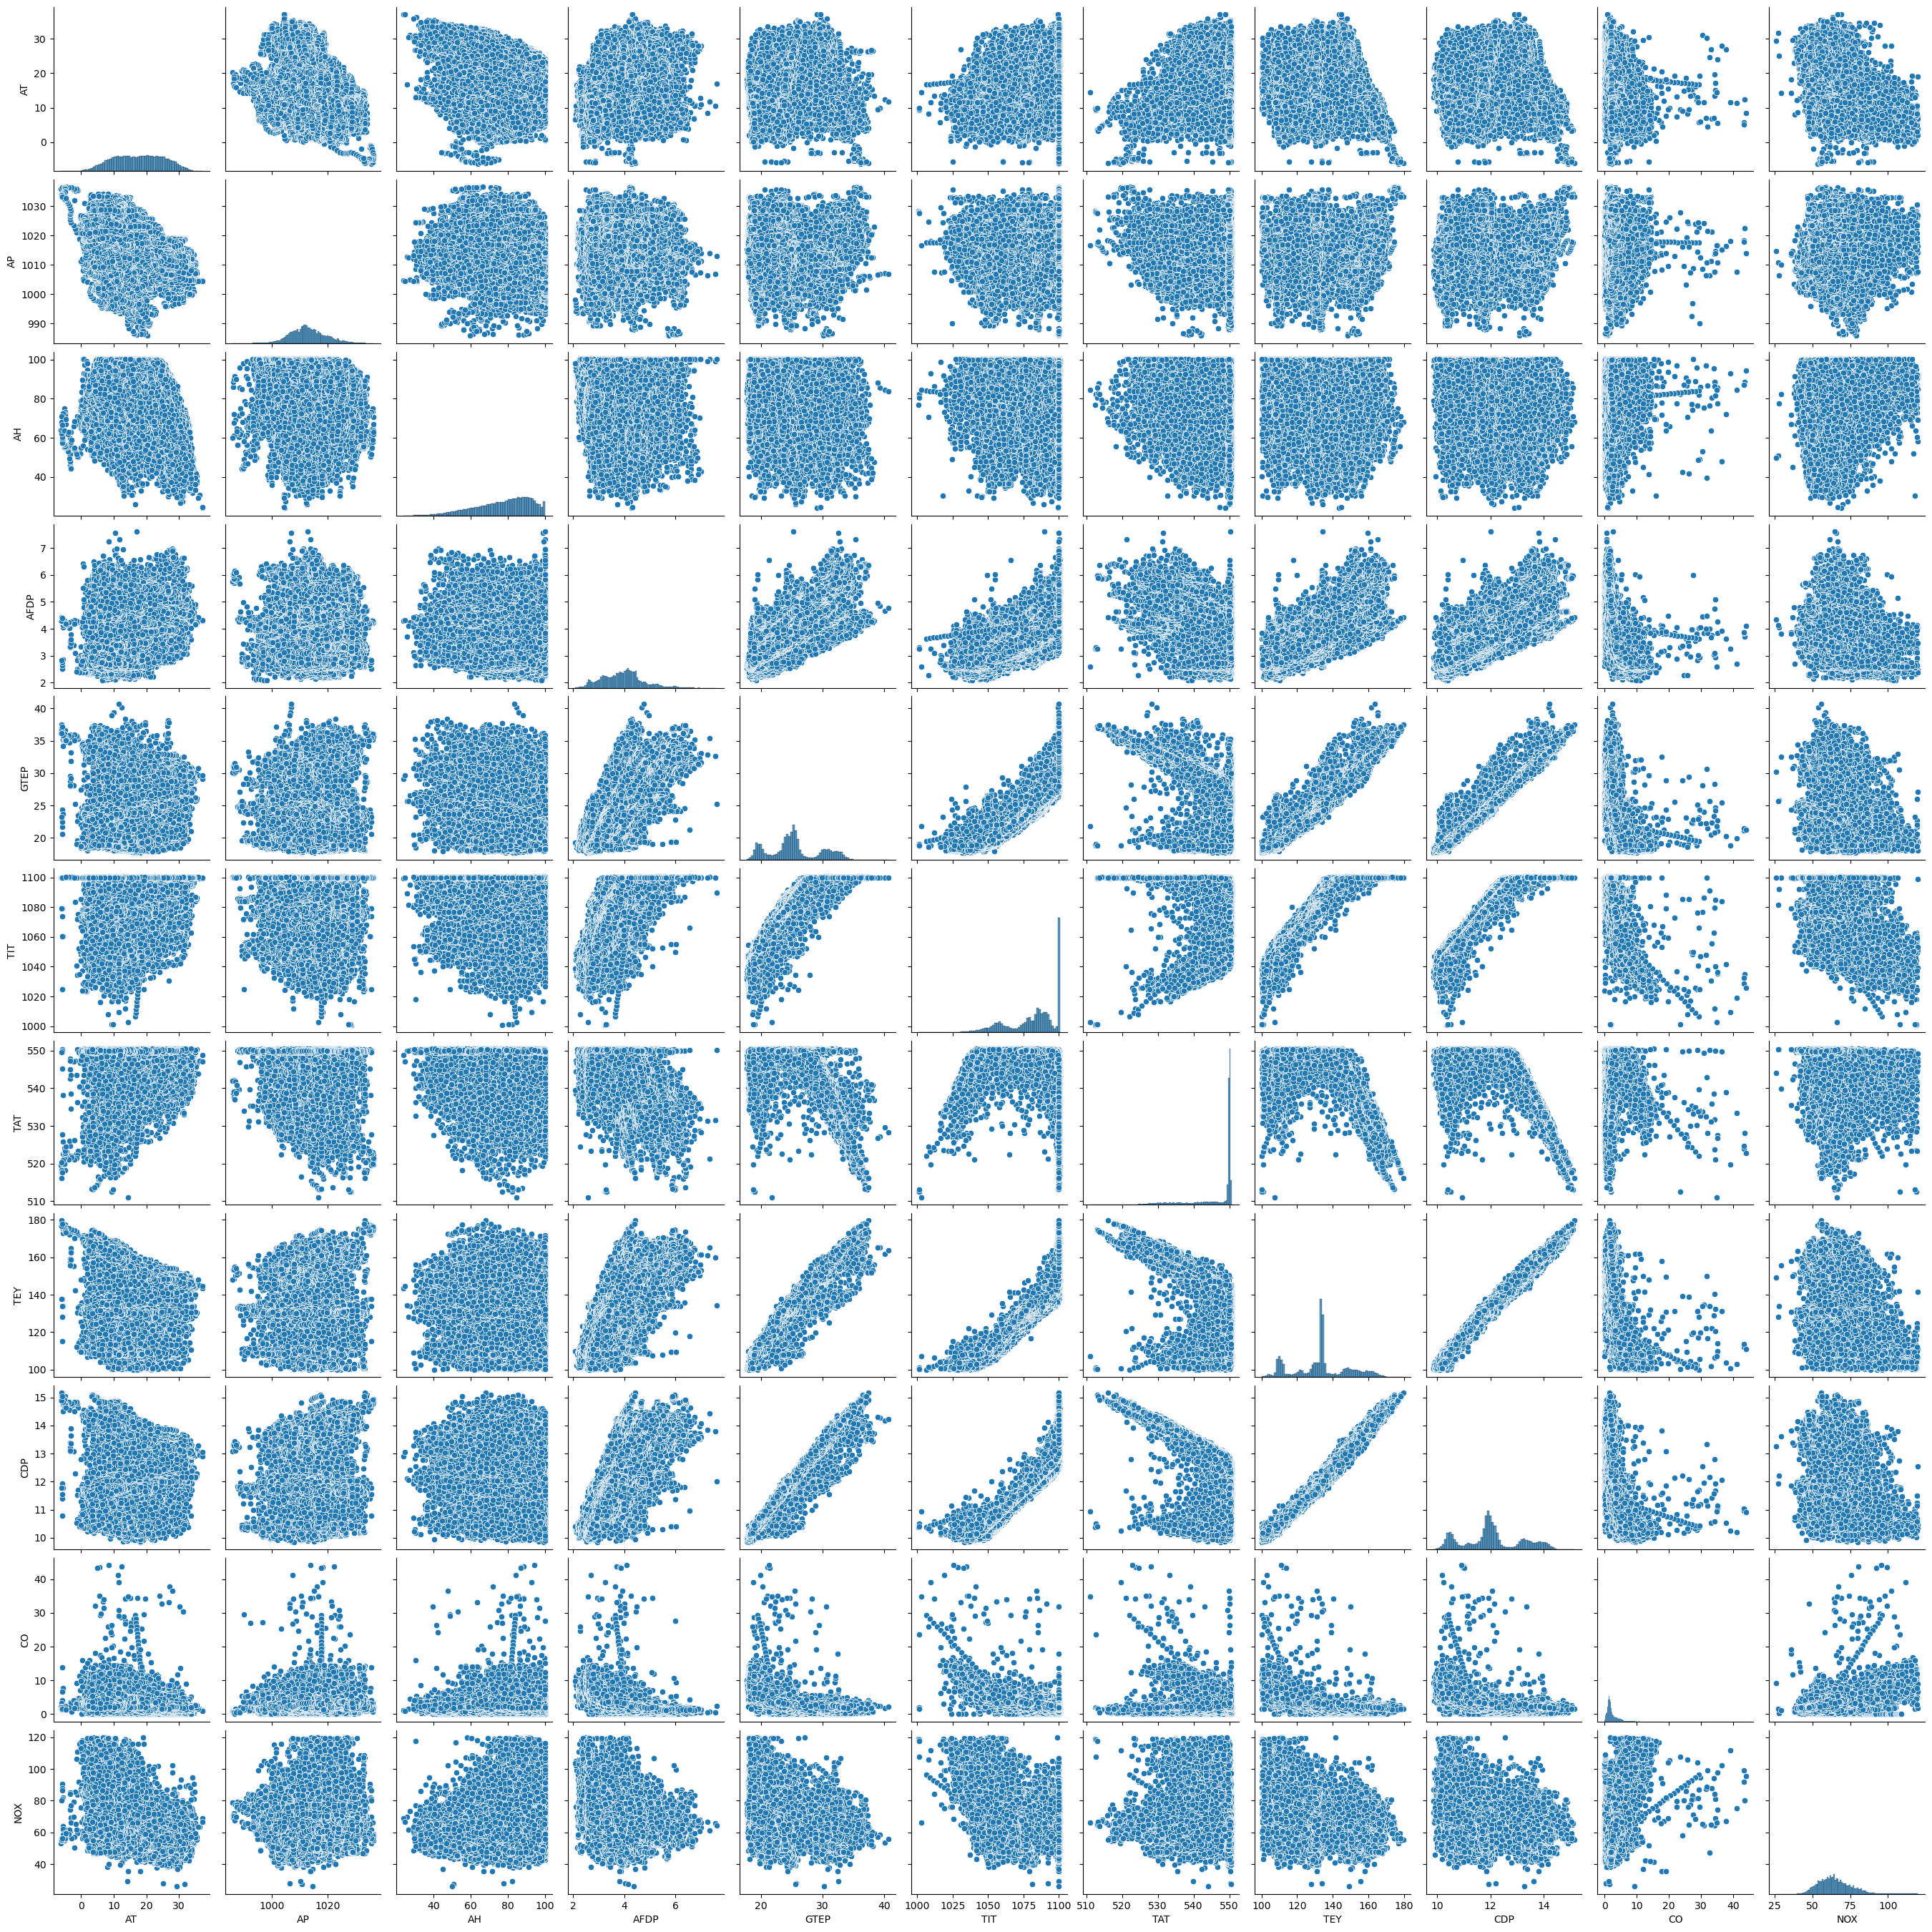

In [12]:
sns.pairplot(gt_df)

d:\MiniMiniConda\envs\MSE413\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


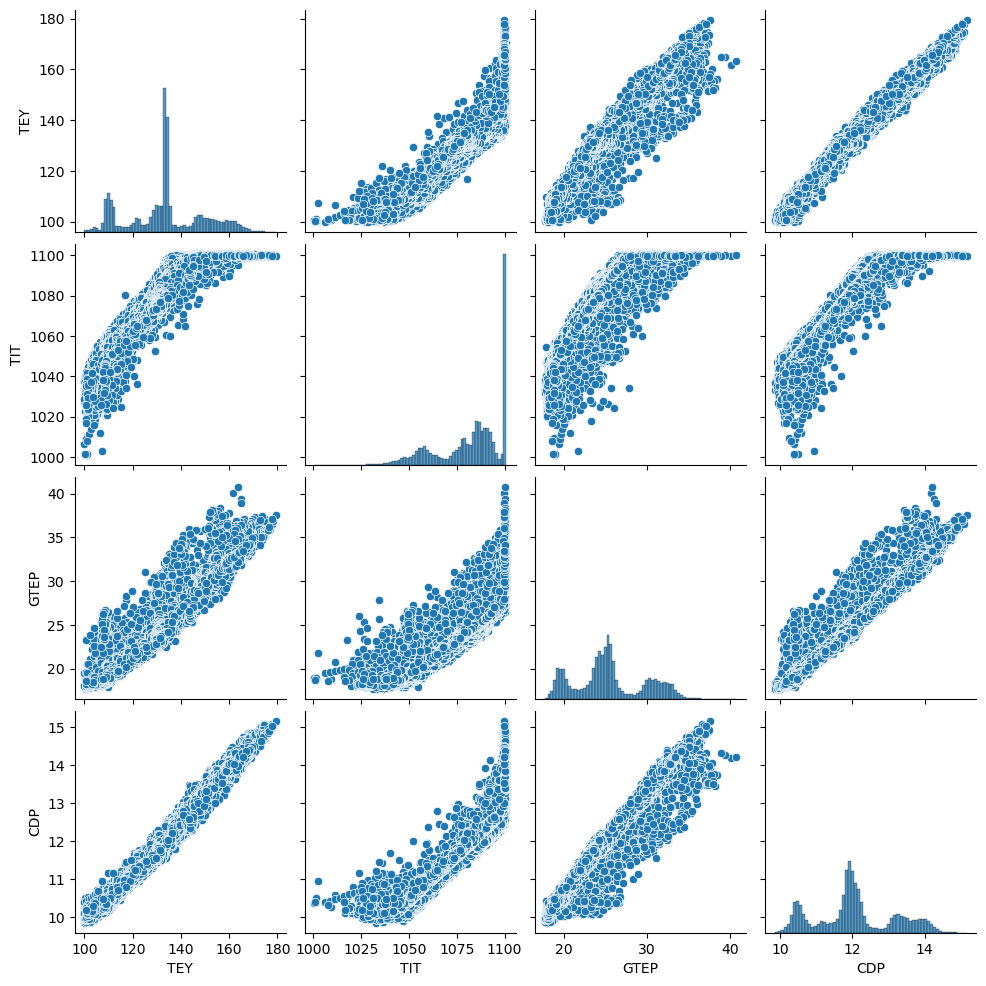

In [13]:
attribute_list = ["TEY", "TIT", "GTEP", "CDP"]
sns.pairplot(gt_df[attribute_list])

In [14]:
from sklearn.model_selection import train_test_split

# Shuffle and split 80 - 20, export to training.csv and testing.csv
# Shuffle and split the data
train_df, test_df = train_test_split(gt_df, test_size=0.2, random_state=42, shuffle=True)

# Export to CSV
train_df.to_csv('training.csv', index=False)
test_df.to_csv('testing.csv', index=False)